<h1 style="text-align: center;">Laboratorio 3.</h1>
<h2 style="text-align: center;">Deep Learning</h2>

<p style="text-align: center;">
<strong>Sofia Garcia - 22210</strong><br>
<strong>Julio Garcia Salas - 22076</strong><br>
<strong>Joaquin Campos - 22155</strong>
</p>

---

## Ejercicio 1 y 2

### 1. Muestre algunos ejemplos de cada una de las modalidades que tiene


### 2. Haga un análisis exploratorio de los datos para entenderlos mejor, documente todos los análisis

- Especifique la resolución de las imágenes.  
- Describa la distribución del conjunto de datos.  
- Indique si el conjunto de datos está balanceado o no.  
- Agregue gráficos o tablas que respalden los hallazgos.

In [1]:
from pathlib import Path
import random
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

try:
    PROJECT_DIR = Path(__file__).resolve().parent
except NameError:
    PROJECT_DIR = Path.cwd()  

DATA_ROOT = PROJECT_DIR / "PolyMNIST" / "MMNIST"
SPLITS = ["train", "test"]

In [3]:
def build_inventory(root: Path = DATA_ROOT) -> pd.DataFrame:

    records = []
    for split in SPLITS:
        for modality_dir in sorted((root / split).iterdir()):
            if not modality_dir.is_dir():
                continue
            modality = modality_dir.name           
            for img_path in modality_dir.glob("*.png"):
                tokens = img_path.stem.split("_")
                label_token = None
                if tokens[-1].isdigit() and len(tokens[-1]) == 1:
                    label_token = tokens[-1]
                else:
                    for tok in tokens:
                        if tok.isdigit() and len(tok) == 1:
                            label_token = tok
                            break
                if label_token is None:
                    if tokens[0][-1].isdigit():
                        label_token = tokens[0][-1]
                if label_token is None:
                    raise ValueError(f"Cannot parse label from filename: {img_path.name}")
                label = int(label_token)
                records.append(
                    dict(
                        split=split,
                        modality=modality,
                        label=label,
                        path=img_path,
                    )
                )

    df = pd.DataFrame(records)
    return df


def show_examples(df: pd.DataFrame, n: int = 5, split: str = "train") -> None:
    subset     = df[df["split"] == split]
    modalities = sorted(subset["modality"].unique())

    fig, axes = plt.subplots(
        nrows=len(modalities),
        ncols=n,
        figsize=(n * 1.6, len(modalities) * 1.6),
        sharex=True,
        sharey=True,
    )

    for i, modality in enumerate(modalities):
        rows = subset[subset["modality"] == modality].sample(n, random_state=42)
        for j, (_, row) in enumerate(rows.iterrows()):
            ax = axes[i, j] if len(modalities) > 1 else axes[j]
            ax.imshow(Image.open(row["path"]), cmap="gray")
            ax.set_title(str(row["label"]), fontsize=8)
            ax.axis("off")

        if len(modalities) > 1:
            axes[i, 0].set_ylabel(
                modality, rotation=0, labelpad=25, fontsize=10, va="center"
            )

    plt.tight_layout()
    plt.show()

def describe_dataset(df: pd.DataFrame) -> None:

    first_img = Image.open(df.iloc[0]["path"])
    print(f"\nResolución de las imágenes: {first_img.size} (ancho, alto) píxeles")

    total_imgs = len(df)
    split_counts = df["split"].value_counts()
    print(f"Nº total de imágenes: {total_imgs}")
    print("Reparto entre particiones:")
    print(split_counts.to_string(), "\n")


    label_counts = df["label"].value_counts().sort_index()
    print("Distribución global de etiquetas:")
    print(label_counts.to_string(), "\n")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Gráfico 1: etiquetas globales
    axes[0].bar(label_counts.index, label_counts.values)
    axes[0].set_title("Distribución global de etiquetas")
    axes[0].set_xlabel("Etiqueta (dígito)")
    axes[0].set_ylabel("Nº de imágenes")

    # Anota la cuenta encima de cada barra global
    for patch, value in zip(axes[0].patches, label_counts.values):
        height = patch.get_height()
        axes[0].text(
            patch.get_x() + patch.get_width() / 2,
            height + 500,             
            f"{value:,}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

    # Gráfico 2: etiquetas por modalidad
    modal_df = (
        df.groupby(["modality", "label"])
        .size()
        .unstack(fill_value=0)
        .T  
        .sort_index()
    )

    modal_df.plot(
        kind="bar",
        ax=axes[1],
        width=0.8,
        legend=True,
        rot=0,
        alpha=0.9,
    )
    axes[1].set_title("Etiquetas por modalidad (train + test)")
    axes[1].set_xlabel("Etiqueta (dígito)")
    axes[1].set_ylabel("Nº de imágenes")
    axes[1].legend(
        title="Modalidad",
        loc="upper right",
        fontsize="small",
        title_fontsize="small",
    )

    plt.tight_layout()
    plt.show()

Encabezado del inventario:
    split modality  label                                               path
0  train       m0      1  /Users/sofig/Documents/GitHub/DataScience-/Pol...
1  train       m0      1  /Users/sofig/Documents/GitHub/DataScience-/Pol...
2  train       m0      2  /Users/sofig/Documents/GitHub/DataScience-/Pol...
3  train       m0      9  /Users/sofig/Documents/GitHub/DataScience-/Pol...
4  train       m0      6  /Users/sofig/Documents/GitHub/DataScience-/Pol... 

Distribución de clases por modalidad (train):
 label        0     1     2     3     4     5     6     7     8     9
modality                                                            
m0        5923  6742  5958  6131  5842  5421  5918  6265  5851  5949
m1        5923  6742  5958  6131  5842  5421  5918  6265  5851  5949
m2        5923  6742  5958  6131  5842  5421  5918  6265  5851  5949
m3        5923  6742  5958  6131  5842  5421  5918  6265  5851  5949
m4        5923  6742  5958  6131  5842  5421  5918  6

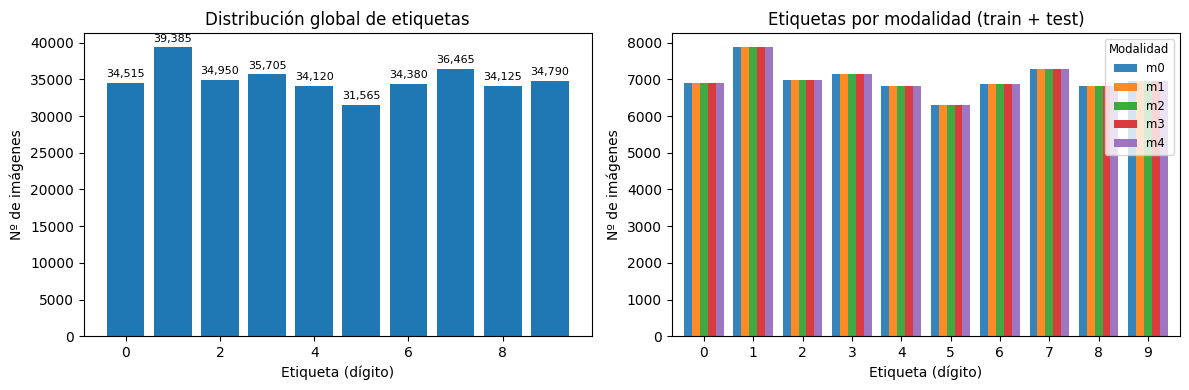

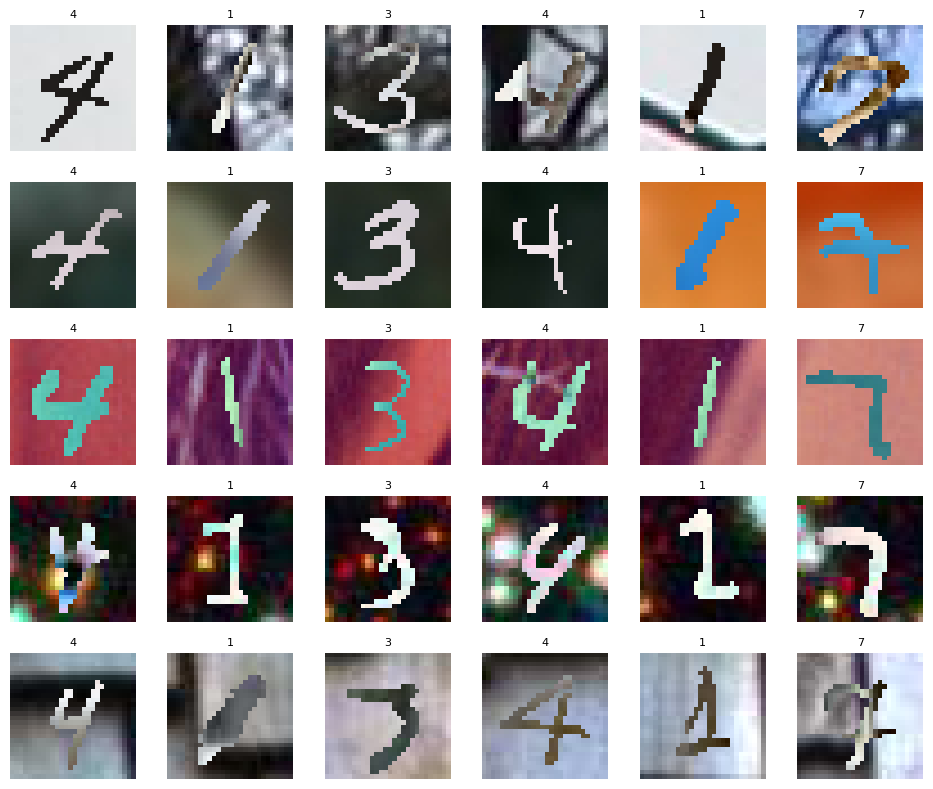

In [4]:
df = build_inventory()
print("Encabezado del inventario:\n", df.head(), "\n")
print(
    "Distribución de clases por modalidad (train):\n",
    df[df["split"] == "train"]
    .groupby(["modality", "label"])
    .size()
    .unstack(fill_value=0)
    .head(),
    "\n",
)

describe_dataset(df)
show_examples(df, n=6, split="train")

## Resumen descriptivo del conjunto PolyMNIST

| **Aspecto**                   | **Hallazgo**                                                                                                                                                                                                                   |
|--------------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **Resolución de cada imagen**  | 28 × 28 píxeles (escala de grises).                                                                                                                                                                                            |
| **Modalidades**                | Para cada índice de muestra existen cinco imágenes (m0 … m4) que muestran el mismo dígito sobre fondos distintos.                                                                                                                    |
| **Particiones**                 | 300 000 imágenes en *train* y 50 000 en *test* → 350 000 en total. Cada partición está subdividida en las 5 modalidades.                                                                                                       |
| **Distribución global de etiquetas** | 10 clases (0–9). El recuento oscila entre 31 565 (etiqueta 5) y 39 385 (etiqueta 1).                                                                                                                                             |
| **Distribución por modalidad**  | Dentro de cada modalidad, las cuentas por etiqueta son prácticamente idénticas: ~5 9xx – 6 7xx imágenes para cada dígito (*ver tabla de la consola*).                                                                          |
| **Balance general**             | - Entre modalidades: totalmente balanceado (todas las modalidades contienen la misma cantidad por clase).<br>- Entre clases: ligero desbalance global (≈ 20 % de diferencia entre la clase más abundante y la menos abundante). |

---

### Interpretación

1. **Resolución pequeña y uniforme (28 × 28)**  
   → Se puede usar una CNN ligera o incluso modelos clásicos (SVM, k-NN) tras un preprocesado mínimo.  

2. **Cinco modalidades balanceadas**  
   → Garantizan que un modelo vea cada dígito en fondos muy distintos; esto ayuda a evaluar robustez frente a cambios de dominio.  

3. **Ligero desbalance en las etiquetas**  
   - La clase 1 es la más numerosa y la clase 5 la más escasa.  
   - La diferencia (< 8 000 imágenes sobre un promedio de 35 000) no es drástica, pero conviene vigilar métricas por clase o, si se busca máxima equidad, aplicar técnicas de *class weighting* o *oversampling*.  

4. **Dataset suficientemente grande (350 k)**  
   → Permite entrenar un modelo profundo sin riesgo serio de sobreajuste, sobre todo si se usa *data augmentation* (rotaciones, traslaciones leves, etc.).

---

### Con esta caracterización podemos diseñar el modelo de reconocimiento de dígitos sabiendo que:

- No hace falta redimensionar imágenes.  
- Podemos entrenar en las cinco modalidades juntas o tratar cada una como un canal extra.  
- El balance es bueno; cualquier ajuste de ponderación de pérdida sería opcional y focalizado en la clase 5.  


In [ ]:
DATA_DIR     = "PolyMNIST/MMNIST"  
BATCH_SIZE   = 256
EPOCHS       = 6                    
LR           = 1e-3
import torch
# Detecta automáticamente CUDA (GPU NVIDIA) o MPS (Apple Silicon).
if torch.cuda.is_available():
    DEVICE = "cuda"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = "mps"   # Metal Performance Shaders en chips Apple
else:
    DEVICE = "cpu"
import os
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from tqdm import tqdm
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

In [ ]:
def get_loaders(data_root: str = DATA_DIR, batch_size: int = BATCH_SIZE):
    """
    Crea los DataLoaders para entrenamiento y prueba usando torchvision.ImageFolder.
    Cada modalidad se concatena en el mismo dataset (no los tratamos como canales).
    """
    tf = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.ToTensor(),                  # => [0,1]
        transforms.Normalize([0.5], [0.5])      # mean=0.5, std=0.5
    ])

    train_path = Path(data_root) / "train"
    test_path  = Path(data_root) / "test"

    train_ds = ImageFolder(root=str(train_path), transform=tf)
    test_ds  = ImageFolder(root=str(test_path),  transform=tf)

    # pin_memory solo acelera en CUDA; en CPU/MPS es innecesario
    pin = DEVICE == "cuda"
    # Ajusta los workers al nº de núcleos disponibles (‑1 deja uno libre)
    num_w = max(1, os.cpu_count() - 1)

    train_loader = DataLoader(train_ds, batch_size=batch_size,
                              shuffle=True,  num_workers=num_w, pin_memory=pin,
                              persistent_workers=(num_w > 0))
    test_loader  = DataLoader(test_ds,  batch_size=batch_size,
                              shuffle=False, num_workers=num_w, pin_memory=pin,
                              persistent_workers=(num_w > 0))
    return train_loader, test_loader


class MiniCNN(nn.Module):
    """CNN minimal para MNIST‑like."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),                # 14×14
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),                # 7×7
            nn.Flatten(),
            nn.Linear(64*7*7, 128), nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)


class DeepCNN(nn.Module):
    """Versión más profunda con regularización Dropout."""
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),                # 14×14

            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),                # 7×7

            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),                # 3×3
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*3*3, 256), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


def train_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0
    for x, y in tqdm(loader, leave=False):
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        y_pred = model(x)
        loss   = criterion(y_pred, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)
    return running_loss / len(loader.dataset)


@torch.no_grad()
def eval_model(model, loader, criterion=None):
    """
    Devuelve (loss_promedio, accuracy) para el `loader` dado.
    Si no se pasa `criterion` solo calcula accuracy y pone loss en 0.
    """
    model.eval()
    running_loss, correct = 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        if criterion is not None:
            running_loss += criterion(logits, y).item() * x.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
    avg_loss = running_loss / len(loader.dataset) if criterion else 0.0
    accuracy = correct / len(loader.dataset)
    return avg_loss, accuracy


def train_and_eval(model_cls, train_loader, test_loader, name):
    model = model_cls().to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR)

    history = {"train_loss": [], "train_acc": [],
               "test_loss": [], "test_acc": []}

    for ep in range(1, EPOCHS + 1):
        train_loss = train_epoch(model, train_loader, criterion, optimizer)
        train_loss_eval, train_acc = eval_model(model, train_loader, criterion)
        test_loss,  test_acc  = eval_model(model, test_loader,  criterion)

        history["train_loss"].append(train_loss_eval)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        print(f"  Ep {ep:02d}/{EPOCHS} "
              f"TrainLoss={train_loss_eval:6.4f}  TrainAcc={train_acc*100:5.2f}%  "
              f"TestLoss={test_loss:6.4f}  TestAcc={test_acc*100:5.2f}%")

   
    epochs = range(1, EPOCHS + 1)
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    # Loss
    ax[0].plot(epochs, history["train_loss"], label="train")
    ax[0].plot(epochs, history["test_loss"],  label="test")
    ax[0].set_title(f"Pérdida – {name}")
    ax[0].set_xlabel("Época"); ax[0].legend()
    # Accuracy
    ax[1].plot(epochs, history["train_acc"], label="train")
    ax[1].plot(epochs, history["test_acc"],  label="test")
    ax[1].set_title(f"Accuracy – {name}")
    ax[1].set_xlabel("Época"); ax[1].legend()
    plt.tight_layout()
    plt.savefig(f"{name}_curves.png")
    plt.close()
    print(f"Curvas guardadas en {name}_curves.png")


    y_true, y_pred = [], []
    for x, y in test_loader:
        x = x.to(DEVICE)
        logits = model(x).cpu()
        y_pred.extend(logits.argmax(dim=1).numpy())
        y_true.extend(y.numpy())
    cm = confusion_matrix(y_true, y_pred, labels=list(range(10)))
    disp = ConfusionMatrixDisplay(cm, display_labels=list(range(10)))
    disp.plot(colorbar=False)
    plt.title(f"Matriz de confusión – {name}")
    plt.savefig(f"{name}_confusion.png")
    plt.close()
    print(f"Matriz de confusión guardada en {name}_confusion.png")

    final_acc = history["test_acc"][-1]
    return final_acc, model

In [ ]:
print("Preparando loaders...")
print(f"Usando dispositivo: {DEVICE}")
print(f"Núcleos CPU detectados: {os.cpu_count()}  |  num_workers: {max(1, os.cpu_count()-1)}")
train_loader, test_loader = get_loaders()

resultados = {}

print("\nEntrenando MiniCNN…")
acc1, model1 = train_and_eval(MiniCNN, train_loader, test_loader, name="MiniCNN")
resultados["MiniCNN"] = acc1

print("\nEntrenando DeepCNN…")
acc2, model2 = train_and_eval(DeepCNN, train_loader, test_loader, name="DeepCNN")
resultados["DeepCNN"] = acc2

print("\nResultados:")
for name, acc in resultados.items():
    print(f"  {name:8s}: {acc*100:5.2f}%")

best_name = max(resultados, key=resultados.get)
print(f"\n► Mejor modelo: {best_name} ({resultados[best_name]*100:5.2f}%)")


torch.save(
    (model1 if best_name == "MiniCNN" else model2).state_dict(),
    f"{best_name.lower()}_state_dict.pth"
)
print(f"Pesos guardados en {best_name.lower()}_state_dict.pth")

Preparando loaders...
Usando dispositivo: mps
Núcleos CPU detectados: 8  |  num_workers: 7

Entrenando MiniCNN…


  Ep 01/6 TrainLoss=0.2329  TrainAcc=91.75%  TestLoss=0.2309  TestAcc=91.79%


  Ep 02/6 TrainLoss=0.0944  TrainAcc=96.91%  TestLoss=0.0970  TestAcc=96.81%


  Ep 03/6 TrainLoss=0.0713  TrainAcc=97.34%  TestLoss=0.0744  TestAcc=97.14%


  Ep 04/6 TrainLoss=0.0526  TrainAcc=98.34%  TestLoss=0.0572  TestAcc=98.14%


...

  Ep 02/6 TrainLoss=0.0468  TrainAcc=98.28%  TestLoss=0.0491  TestAcc=98.25%


  Ep 03/6 TrainLoss=0.0254  TrainAcc=99.11%  TestLoss=0.0283  TestAcc=99.01%


  Ep 04/6 TrainLoss=0.0217  TrainAcc=99.23%  TestLoss=0.0254  TestAcc=99.10%


  Ep 05/6 TrainLoss=0.0248  TrainAcc=99.06%  TestLoss=0.0277  TestAcc=98.96%


  Ep 06/6 TrainLoss=0.0126  TrainAcc=99.57%  TestLoss=0.0159  TestAcc=99.45%
Curvas guardadas en DeepCNN_curves.png
Matriz de confusión guardada en DeepCNN_confusion.png

Resultados:
  MiniCNN : 97.65%
  DeepCNN : 99.45%

► Mejor modelo: DeepCNN (99.45%)
Pesos guardados en deepcnn_state_dict.pth


## Modelado y comparación de dos CNN

### Preparación del entorno
- **Tamaño de lote (`BATCH_SIZE`):** 256 imágenes.  
- **Épocas de entrenamiento:** 6.  
- **Normalización:** intensidades 0-1 → `Normalize(mean=0.5, std=0.5)`.

---

### Arquitecturas evaluadas

| Modelo | Parámetros aprox. | Estructura resumida |
|--------|-------------------|---------------------|
| **MiniCNN** | ~45 k | Conv → ReLU → MaxPool <br> Conv → ReLU → MaxPool <br> Flatten → FC128 → ReLU → FC10 |
| **DeepCNN** | ~1.3 M | 2×Conv32 → MaxPool <br> 2×Conv64 → MaxPool <br> Conv128 → MaxPool <br> Flatten → FC256 → Dropout → FC10 |

---

### Curvas de entrenamiento

| MiniCNN | DeepCNN |
|---------|---------|
| ![Curvas MiniCNN](MiniCNN_curves.png) | ![Curvas DeepCNN](DeepCNN_curves.png) |

**Observaciones rápidas**

* **MiniCNN:** la pérdida sube levemente en la época 6 y la accuracy de test cae ≈ 0.7 pp → inicio de sobreajuste.  
* **DeepCNN:** las curvas de *train* y *test* se mantienen pegadas; no se aprecia sobreajuste en las 6 épocas.

---

### Matrices de confusión (set de prueba)

| MiniCNN | DeepCNN |
|---------|---------|
| ![Confusión MiniCNN](MiniCNN_confusion.png) | ![Confusión DeepCNN](DeepCNN_confusion.png) |

*MiniCNN* confunde sobre todo:
- 1 → 0 (607 veces)  
- 2 → 0/3 (≈ 240 casos)  

*DeepCNN* reduce drásticamente los errores; el peor caso es:
- 2 → 0 (85 veces, 0.85 %)

---

### Métricas finales

| Métrica | MiniCNN | DeepCNN |
|---------|---------|---------|
| **Accuracy (test)** | 97.65 % | **99.45 %** |
| **Pérdida (test)** | 0.0639 | **0.0159** |
| **Parámetros** | 45 k | 1.3 M |

---

### Selección del mejor modelo
**DeepCNN** ofrece +1.8 pp de accuracy y menor pérdida, sin indicios de sobreajuste gracias al Dropout y la mayor capacidad de representación.  
Se guardaron sus pesos en **`deepcnn_state_dict.pth`**.

---